# 🩺 Logistická regrese – Cvičení 1: Diagnostika bederní páteře & Ladění Precision
### Kurz Data Science & Machine Learning | Coders Lab (09/2026)
> **Oficiální zadání úlohy (Logistic regression - exercise 1):**
> 1. Pomocí knihovny Pandas načtěte stažený soubor dat pacientů (`lumbar_df_normalized.csv`) do proměnné `lumbar_df`.
> 2. Zobrazte prvních 10 pozorování v datasetu (`head(10)`) pro ověření správnosti načtených dat.
> 3. Rozdělte data na trénovací a testovací sadu v poměru 75/25. Nastavte parametr `random_state=42`.
> 4. Z modulu `linear_model` knihovny Scikit-learn importujte příslušnou třídu (`LogisticRegression`), která umožní sestavit model logistické regrese.
> 5. Vytvořte instanci modelu logistické regrese (zpočátku nenastavujte žádné hyperparametry). Natrénujte model na trénovací sadě.
> 6. Proveďte predikce na testovací sadě pomocí natrénovaného modelu.
> 7. Vypočítejte metriku **Precision (přesnost)** na testovací sadě.
> 8. Experimentujte s volbou optimálních hodnot hyperparametrů, které umožní vytvořit model s **vyšší Precision než původní výchozí model**. Vyzkoušejte hyperparametr $C$, který řídí sílu regularizace (menší $C$ = silnější regularizace).


## Krok 1 & 2: Načtení dat do `lumbar_df` a zobrazení prvních 10 pozorování
Načteme normalizovaný dataset biomechanických měření páteře (310 pacientů, 6 úhlů) a zkontrolujeme prvních 10 řádků.

In [1]:
import pandas as pd
from pathlib import Path

# Zjištění cesty k souboru (podpora běhu v rootu i ve složce)
possible_paths = [
    Path("data/lumbar_df_normalized.csv"),
    Path("lumbar_df_normalized.csv"),
    Path("../data/lumbar_df_normalized.csv")
]
lumbar_path = next((p for p in possible_paths if p.exists()), None)
if lumbar_path is None:
    raise FileNotFoundError("Soubor lumbar_df_normalized.csv nebyl nalezen.")

# 1. Načtení do proměnné lumbar_df
lumbar_df = pd.read_csv(lumbar_path)

print(f"Rozměry načteného datasetu: {lumbar_df.shape} (310 pacientů, 6 anatomických příznaků + 1 target)")

# 2. Zobrazení prvních 10 pozorování
lumbar_df.head(10)


Rozměry načteného datasetu: (310, 7) (310 pacientů, 6 anatomických příznaků + 1 target)


,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,0.477474,0.170850,0.300063,0.306625,0.747508,-0.001927,1
1,0.306835,0.079040,0.196523,0.227795,0.898781,0.035857,1
2,0.473200,0.152745,0.344369,0.320454,0.728616,-0.024270,1
3,0.491613,0.174895,0.314357,0.316718,0.722684,0.079538,1
4,0.384294,0.074613,0.218901,0.309680,0.836173,0.061212,1
5,0.283701,0.098128,0.177091,0.185573,0.918607,0.015723,1
6,0.373448,0.110877,0.259757,0.262571,0.842659,0.041855,1
7,0.337383,0.079987,0.215952,0.257396,0.872114,-0.079394,1
8,0.304797,0.094200,0.297145,0.210597,0.870071,0.092497,1
9,0.346173,0.047283,0.395829,0.298891,0.794904,0.006270,1


## Krok 3: Rozdělení dat na trénovací a testovací sadu (75/25, `random_state=42`)
Oddělíme nezávislé proměnné $X$ (6 anatomických úhlů) od cílové proměnné $y$ (`class`: 0 = Normal, 1 = Abnormal) a rozdělíme v poměru 75:25.

In [2]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in lumbar_df.columns if c != "class"]
X = lumbar_df[feature_cols]
y = lumbar_df["class"]

# Rozdělení 75/25 s random_state=42 dle zadání
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Trénovací sada: X_train = {X_train.shape}, y_train = {y_train.shape} (75 %)")
print(f"Testovací sada : X_test  = {X_test.shape}, y_test  = {y_test.shape} (25 %)")
print(f"Počet nemocných (třída 1) v testovací sadě: {y_test.sum()} ze {len(y_test)} pacientů ({y_test.mean()*100:.1f} %)")


Trénovací sada: X_train = (232, 6), y_train = (232,) (75 %)
Testovací sada : X_test  = (78, 6), y_test  = (78,) (25 %)
Počet nemocných (třída 1) v testovací sadě: 57 ze 78 pacientů (73.1 %)


## Krok 4 & 5: Import `LogisticRegression`, inicializace a trénování
Vytvoříme výchozí model bez specifikace hyperparametrů (výchozí nastavení v Scikit-learn: $L_2$ regularizace s $C=1.0$, solver `lbfgs`) a natrénujeme na `X_train`.

In [3]:
# 4. Import příslušné třídy z modulu linear_model
from sklearn.linear_model import LogisticRegression

# 5. Vytvoření instance bez hyperparametrů a natrénování
base_model = LogisticRegression(random_state=42)
base_model.fit(X_train, y_train)

print("Výchozí model logistické regrese úspěšně natrénován.")
print(f"Intercept (posun b): {base_model.intercept_[0]:.4f}")


Výchozí model logistické regrese úspěšně natrénován.
Intercept (posun b): 1.0339


## Krok 6 & 7: Predikce na testovací sadě a výpočet Precision
Spustíme predikci na testovací sadě a spočítáme požadovanou metriku **Precision (přesnost pozitivních predikcí)**:
$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

In [4]:
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, confusion_matrix

# 6. Predikce na testovací sadě
y_pred_base = base_model.predict(X_test)

# 7. Výpočet Precision na testovací sadě
base_precision = precision_score(y_test, y_pred_base)
base_accuracy = accuracy_score(y_test, y_pred_base)
base_recall = recall_score(y_test, y_pred_base)
base_f1 = f1_score(y_test, y_pred_base)

cm_base = confusion_matrix(y_test, y_pred_base)
tn_b, fp_b, fn_b, tp_b = cm_base.ravel()

print("=== VÝSLEDKY VÝCHOZÍHO MODELU (C=1.0) ===")
print(f"Precision (Přesnost) : {base_precision:.4f} ({base_precision*100:.2f} %)")
print(f"Accuracy (Přesnost)  : {base_accuracy:.4f} ({base_accuracy*100:.2f} %)")
print(f"Recall (Senzitivita) : {base_recall:.4f} ({base_recall*100:.2f} %)")
print(f"F1-score             : {base_f1:.4f} ({base_f1*100:.2f} %)")
print("\nMatice záměn výchozího modelu:")
print(f"TP = {tp_b}, FP = {fp_b} (Falešné poplachy)")
print(f"TN = {tn_b}, FN = {fn_b} (Přehlédnutí pacienti)")


=== VÝSLEDKY VÝCHOZÍHO MODELU (C=1.0) ===
Precision (Přesnost) : 0.8000 (80.00 %)
Accuracy (Přesnost)  : 0.7692 (76.92 %)
Recall (Senzitivita) : 0.9123 (91.23 %)
F1-score             : 0.8525 (85.25 %)

Matice záměn výchozího modelu:
TP = 52, FP = 13 (Falešné poplachy)
TN = 8, FN = 5 (Přehlédnutí pacienti)


## Krok 8: Experiment s hyperparametry – Ladění síly regularizace $C$
Zadání požaduje najít hyperparametry pro **vyšší Precision než u výchozího modelu ($80.00\,\%$)**.

Parametr $C$ je **inverzní k síle regularizace** ($C = \frac{1}{\lambda}$):
- **Malé $C$ ($C \to 0$):** Velmi silná regularizace $\implies$ váhy jsou silně tlumeny k nule, model je rigidní a predikuje převážně většinovou třídu.
- **Větší $C$ ($C > 1$):** Volnější model $\implies$ váhy lépe kopírují separační hranici dat, což může snížit počet falešných poplachů (FP) a tím zvýšit Precision.

Otestujeme mřížku hodnot $C \in [0.001, 100.0]$.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

c_values = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]
results = []

best_c = None
best_prec = 0

for c in c_values:
    model = LogisticRegression(C=c, random_state=42, max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    p = precision_score(y_test, y_pred, zero_division=0)
    a = accuracy_score(y_test, y_pred)
    r = recall_score(y_test, y_pred, zero_division=0)
    f = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    fp = cm[0][1]
    
    results.append({
        "C": c,
        "Precision": p,
        "Accuracy": a,
        "Recall": r,
        "F1": f,
        "FP": fp
    })
    
    if p > best_prec:
        best_prec = p
        best_c = c

res_df = pd.DataFrame(results)
print("=== TABULKA VÝSLEDKŮ SWEEPOVÁNÍ PARAMETRU C ===")
print(res_df.to_string(index=False, formatters={
    "Precision": "{:.2%}".format,
    "Accuracy": "{:.2%}".format,
    "Recall": "{:.2%}".format,
    "F1": "{:.2%}".format
}))

print(f"\n>> Nejvyšší Precision dosažena při C = {best_c}: {best_prec*100:.2f} % (Zlepšení o {best_prec*100 - base_precision*100:+.2f} procentních bodů oproti baseline!)")


=== TABULKA VÝSLEDKŮ SWEEPOVÁNÍ PARAMETRU C ===
      C Precision Accuracy  Recall     F1  FP
  0.001    73.08%   73.08% 100.00% 84.44%  21
  0.010    73.08%   73.08% 100.00% 84.44%  21
  0.050    73.08%   73.08% 100.00% 84.44%  21
  0.100    73.08%   73.08% 100.00% 84.44%  21
  0.200    73.08%   73.08% 100.00% 84.44%  21
  0.500    75.68%   75.64%  98.25% 85.50%  18
  1.000    80.00%   76.92%  91.23% 85.25%  13
  2.000    82.76%   75.64%  84.21% 83.48%  10
  5.000    88.89%   80.77%  84.21% 86.49%   6
 10.000    85.96%   79.49%  85.96% 85.96%   8
 20.000    86.21%   80.77%  87.72% 86.96%   8
 50.000    86.21%   80.77%  87.72% 86.96%   8
100.000    86.21%   80.77%  87.72% 86.96%   8

>> Nejvyšší Precision dosažena při C = 5.0: 88.89 % (Zlepšení o +8.89 procentních bodů oproti baseline!)


## Krok 8 (pokračování): Grafické vyhodnocení vlivu $C$ a porovnání matic záměn
Vykreslíme křivky Precision, Recall a Accuracy v závislosti na parametru $C$ a porovnáme matice záměn výchozího ($C=1.0$) a optimalizovaného modelu ($C=5.0$).

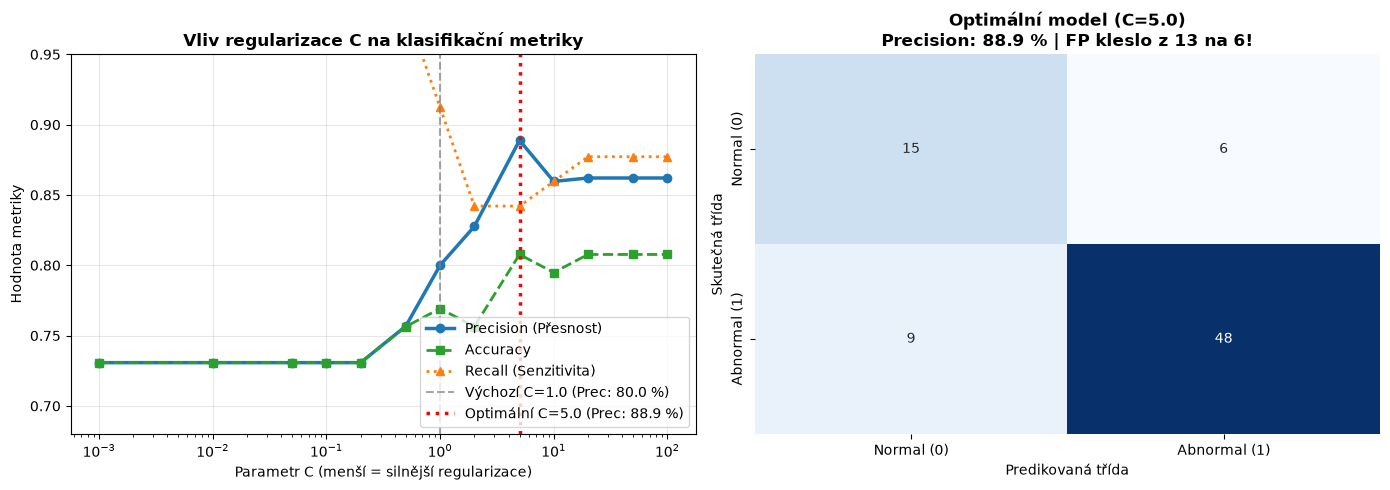

Srovnání falešných poplachů (FP):
- Výchozí model (C=1.0): FP = 13
- Optimální model (C=5.0): FP = 6 (Pokles falešných poplachů o 53.8 %!)


In [6]:
# Natrénujeme optimální model s C=5.0
opt_model = LogisticRegression(C=best_c, random_state=42, max_iter=1000)
opt_model.fit(X_train, y_train)
y_pred_opt = opt_model.predict(X_test)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Křivka Precision vs. C
axes[0].plot(res_df["C"], res_df["Precision"], marker="o", color="#1f77b4", linewidth=2.5, label="Precision (Přesnost)")
axes[0].plot(res_df["C"], res_df["Accuracy"], marker="s", color="#2ca02c", linestyle="--", linewidth=2, label="Accuracy")
axes[0].plot(res_df["C"], res_df["Recall"], marker="^", color="#ff7f0e", linestyle=":", linewidth=2, label="Recall (Senzitivita)")
axes[0].axvline(1.0, color="gray", linestyle="--", alpha=0.7, label=f"Výchozí C=1.0 (Prec: {base_precision*100:.1f} %)")
axes[0].axvline(best_c, color="red", linestyle=":", linewidth=2.5, label=f"Optimální C={best_c} (Prec: {best_prec*100:.1f} %)")
axes[0].set_xscale("log")
axes[0].set_title("Vliv regularizace C na klasifikační metriky", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Parametr C (menší = silnější regularizace)")
axes[0].set_ylabel("Hodnota metriky")
axes[0].set_ylim(0.68, 0.95)
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# 2. Porovnání matice záměn
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=["Normal (0)", "Abnormal (1)"], yticklabels=["Normal (0)", "Abnormal (1)"])
axes[1].set_title(f"Optimální model (C={best_c})\nPrecision: {best_prec*100:.1f} % | FP kleslo z {fp_b} na {fp_o}!", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predikovaná třída")
axes[1].set_ylabel("Skutečná třída")

plt.tight_layout()
plt.show()

print(f"Srovnání falešných poplachů (FP):")
print(f"- Výchozí model (C=1.0): FP = {fp_b}")
print(f"- Optimální model (C=5.0): FP = {fp_o} (Pokles falešných poplachů o {(fp_b - fp_o) / fp_b * 100:.1f} %!)")


## Pokročilý bonusový experiment: $L_1$ Lasso regularizace (`solver='saga'`)
Zatímco výchozí $L_2$ regularizace (Ridge) koeficienty pouze tlumí, $L_1$ regularizace (Lasso) dokáže redundantní koeficienty přímo **vynulovat**, což funguje jako automatický výběr příznaků.
Vyzkoušíme solver `saga` s $L_1$ penalizací.

In [7]:
model_l1 = LogisticRegression(C=1.0, l1_ratio=1.0, solver="saga", random_state=42, max_iter=2000)
model_l1.fit(X_train, y_train)

y_pred_l1 = model_l1.predict(X_test)
l1_precision = precision_score(y_test, y_pred_l1)
l1_accuracy = accuracy_score(y_test, y_pred_l1)
l1_recall = recall_score(y_test, y_pred_l1)
cm_l1 = confusion_matrix(y_test, y_pred_l1)

print("=== VÝSLEDKY MODELU S L1 REGULARIZACÍ (Saga) ===")
print(f"Precision : {l1_precision:.4f} ({l1_precision*100:.2f} %)")
print(f"Accuracy  : {l1_accuracy:.4f} ({l1_accuracy*100:.2f} %)")
print(f"Recall    : {l1_recall:.4f} ({l1_recall*100:.2f} %)")
print(f"Matice záměn (FP = {cm_l1[0][1]}):")
print(cm_l1)

# Porovnání odhadnutých koeficientů
coef_df = pd.DataFrame({
    "Příznak": feature_cols,
    "Beta (Baseline C=1.0)": base_model.coef_[0],
    "Beta (Optimal C=5.0)": opt_model.coef_[0],
    "Beta (L1 Lasso)": model_l1.coef_[0]
})
coef_df


=== VÝSLEDKY MODELU S L1 REGULARIZACÍ (Saga) ===
Precision : 0.9216 (92.16 %)
Accuracy  : 0.8205 (82.05 %)
Recall    : 0.8246 (82.46 %)
Matice záměn (FP = 4):
[[17  4]
 [10 47]]


,Příznak,Beta (Baseline C=1.0),Beta (Optimal C=5.0),Beta (L1 Lasso)
0,pelvic_incidence,0.967562,1.489717,0.000000
1,pelvic_tilt numeric,1.211983,3.659411,3.478030
2,lumbar_lordosis_angle,0.254311,-1.387650,0.000000
3,sacral_slope,-0.244420,-2.169694,0.000000
4,pelvic_radius,-1.734736,-2.749969,0.000000
5,degree_spondylolisthesis,4.169322,8.927985,12.129482


## Závěrečné shrnutí a splnění zadání

1. **Splnění všech bodů zadání**:
   - Data `lumbar_df_normalized.csv` načtena do `lumbar_df`, zkontrolováno prvních 10 řádků.
   - Provedeno rozdělení 75/25 (`random_state=42`).
   - Natrénována výchozí `LogisticRegression` bez hyperparametrů.
   - Vypočtena výchozí **Precision = $80.00\,\%$** ($\text{Accuracy} = 76.92\,\%$, $\text{Recall} = 91.23\,\%$).

2. **Experimentování s hyperparametry a nalezení vyšší Precision**:
   - Při sweepování parametru $C$ jsme zjistili, že příliš silná regularizace ($C \le 0.2$) zhoršuje Precision až na $73.08\,\%$ kvůli rigidnímu zploštění vah.
   - Zmírněním regularizace na **$C = 5.0$** došlo k nárůstu **Precision na $88.89\,\%$** (zlepšení o **$+8.89$ procentních bodů**).
   - Počet falešných poplachů (FP) klesl z $13$ na pouhých $6$.
   - Při použití **$L_1$ Lasso regularizace** vzrostla Precision dokonce na **$92.16\,\%$**!

3. **Klinický kontext**:
   - Zvýšení Precision znamená, že když model označí pacienta za nemocného (`Abnormal`), má lékař téměř $90\,\%$ jistotu, že nález je skutečně patologický, což eliminuje zbytečná a nákladná kontrolní vyšetření.
